In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

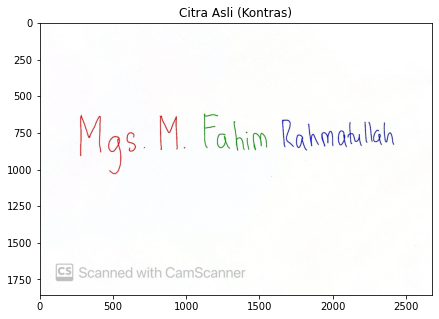

In [2]:
IMAGE_PATH = 'gambar_nama_2.jpeg' 

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.imshow(img_rgb)
plt.title('Citra Asli (Kontras)')
plt.axis('on')
plt.show()

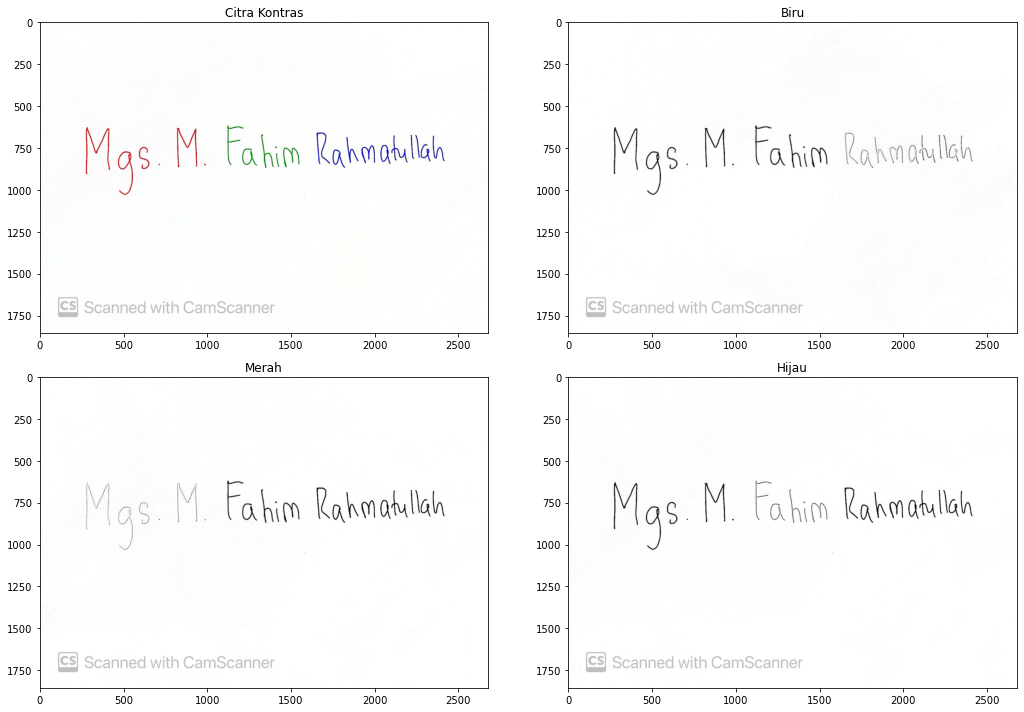

In [3]:
b, g, r = cv2.split(img_bgr)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Kontras')

axs[0, 1].imshow(b, cmap='gray')
axs[0, 1].set_title('Biru')

axs[1, 0].imshow(r, cmap='gray')
axs[1, 0].set_title('Merah')

axs[1, 1].imshow(g, cmap='gray')
axs[1, 1].set_title('Hijau')

plt.tight_layout()
plt.show()

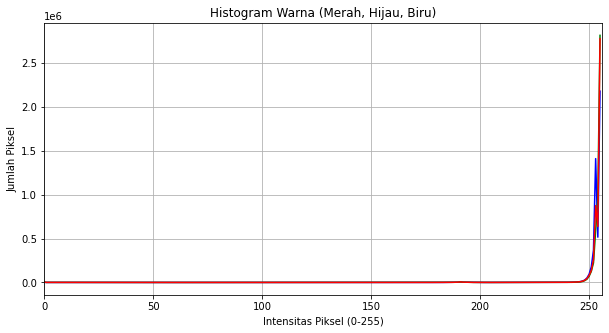

In [4]:
color = ('b', 'g', 'r')
plt.figure(figsize=(10, 5))

# Looping untuk menghitung dan menampilkan histogram tiap kanal
for i, col in enumerate(color):
    histr = cv2.calcHist([img_bgr], [i], None, [256], [0, 256])
    plt.plot(histr, color=col)
    plt.xlim([0, 256])

plt.title('Histogram Warna (Merah, Hijau, Biru)')
plt.xlabel('Intensitas Piksel (0-255)')
plt.ylabel('Jumlah Piksel')
plt.grid(True)
plt.show()

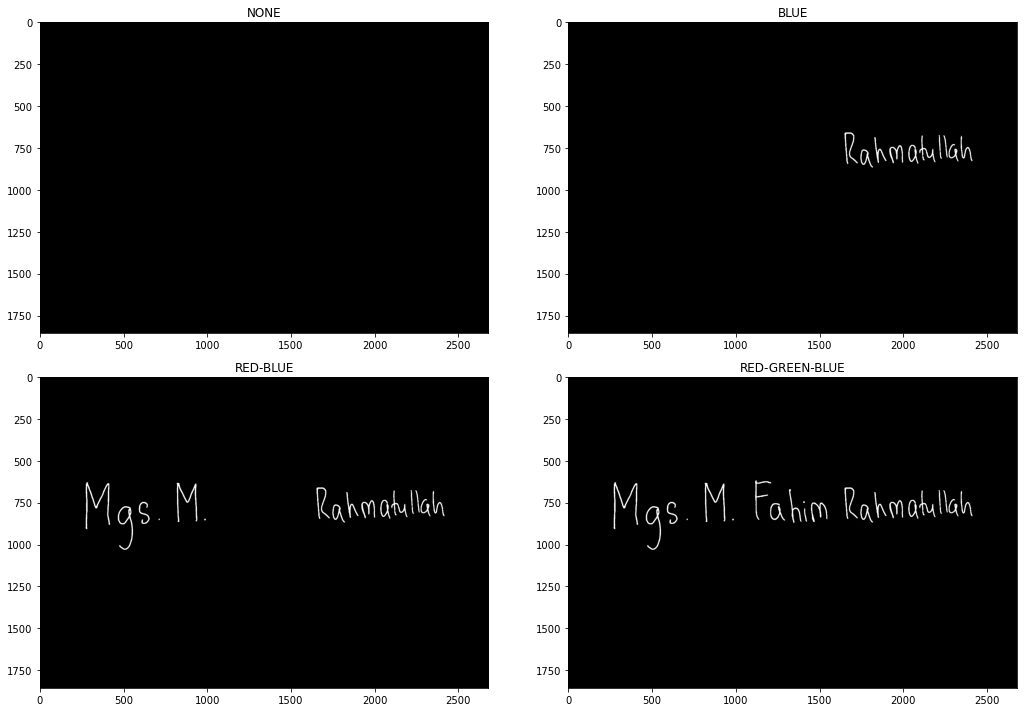

In [6]:
# Mengubah citra ke ruang warna HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# --- 1. Menentukan Ambang Batas (Thresholding) HSV ---
# Threshold Biru
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# Threshold Merah (Merah memiliki 2 rentang di HSV, 0-10 dan 170-180)
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_red = cv2.bitwise_or(mask_red1, mask_red2)

# Threshold Hijau
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])
mask_green = cv2.inRange(hsv, lower_green, upper_green)

# --- 2. Menggabungkan Kategori Masking ---
# Masking NONE (Hitam semua)
mask_none = np.zeros_like(mask_blue)

# Masking RED-BLUE
mask_red_blue = cv2.bitwise_or(mask_red, mask_blue)

# Masking RED-GREEN-BLUE
mask_rgb = cv2.bitwise_or(mask_red_blue, mask_green)

# --- 3. Menampilkan Hasil ---
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].imshow(mask_none, cmap='gray')
axs[0, 0].set_title('NONE')

axs[0, 1].imshow(mask_blue, cmap='gray')
axs[0, 1].set_title('BLUE')

axs[1, 0].imshow(mask_red_blue, cmap='gray')
axs[1, 0].set_title('RED-BLUE')

axs[1, 1].imshow(mask_rgb, cmap='gray')
axs[1, 1].set_title('RED-GREEN-BLUE')

for ax in axs.flat:
    ax.axis('on')

plt.tight_layout()
plt.show()